# Stage 1: Dataset Exploration and Preprocessing

This notebook covers the initial stage of the machine learning pipeline, including dataset loading, exploration, visualization, and preprocessing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
from sklearn.model_selection import train_test_split
import pickle

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load and Explore the Dataset

In [2]:
# Define dataset path
dataset_path = Path('/Users/youssefbarakat/Documents/GitHub/Applied_Machine_Learning_Project_Y2/food_subset')

# Get all class directories
classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}\n")

# Load dataset information
data_info = {}
for class_name in classes:
    class_path = dataset_path / class_name
    images = sorted(list(class_path.glob('*.jpg')))
    data_info[class_name] = len(images)

print("Dataset Overview")

print(f"\nNumber of images per class:")
for class_name, count in data_info.items():
    print(f"{class_name}: {count}")

total_images = sum(data_info.values())
print(f"\nTotal number of images: {total_images}")
print(f"Average images per class: {total_images / len(classes):.2f}")

Number of classes: 10
Classes: ['chocolate_cake', 'donuts', 'falafel', 'french_fries', 'hamburger', 'ice_cream', 'pizza', 'spaghetti_bolognese', 'steak', 'waffles']

Dataset Overview

Number of images per class:
chocolate_cake: 400
donuts: 400
falafel: 400
french_fries: 400
hamburger: 400
ice_cream: 400
pizza: 400
spaghetti_bolognese: 400
steak: 400
waffles: 400

Total number of images: 4000
Average images per class: 400.00


## 2. Display Sample Images

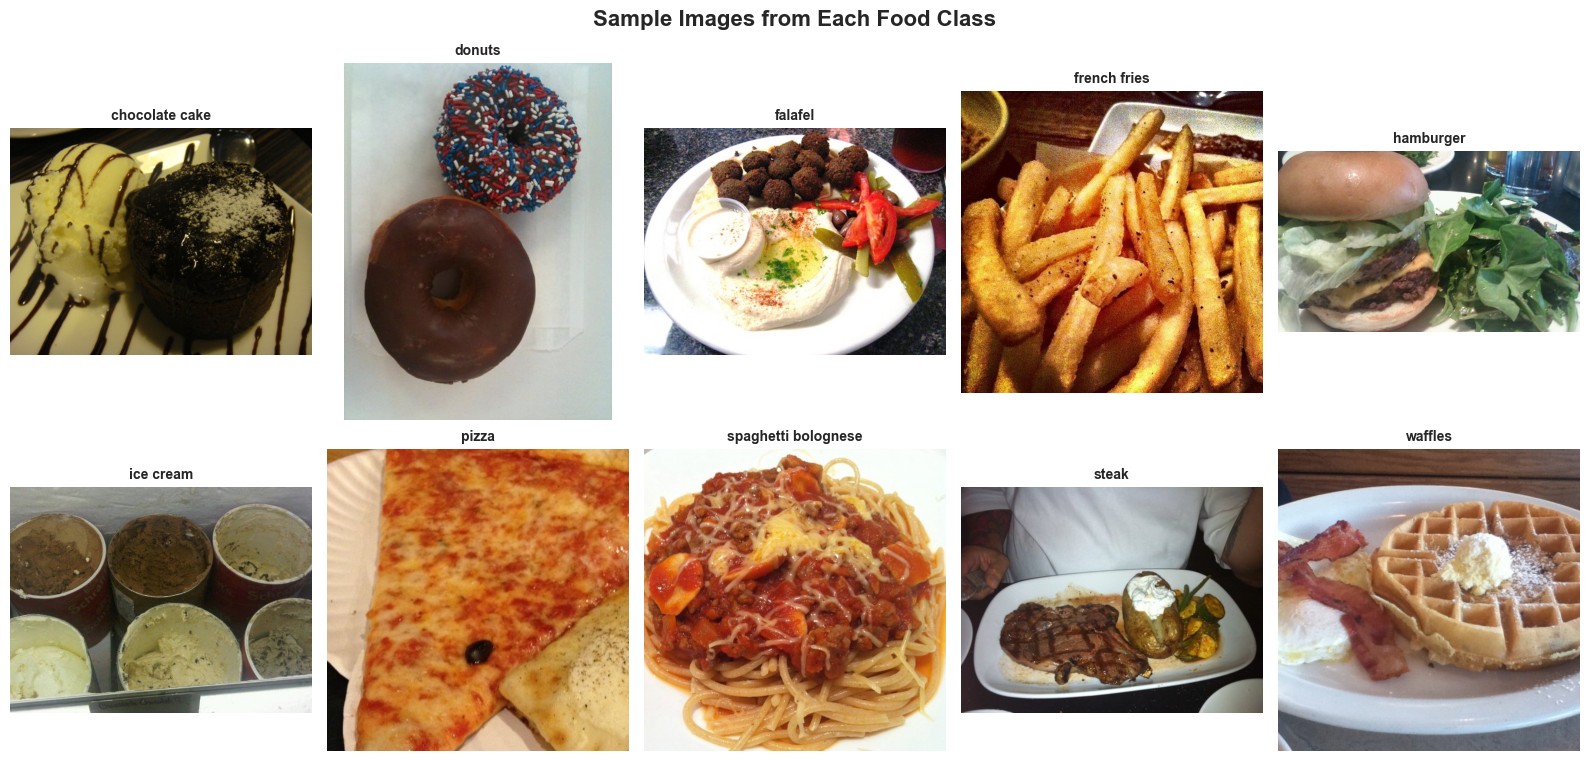

In [4]:
# Display sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('Sample Images from Each Food Class', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, class_name in enumerate(classes):
    class_path = dataset_path / class_name
    images = sorted(list(class_path.glob('*.jpg')))
    if images:
        # Load first image from the class
        img = Image.open(images[1])
        axes[idx].imshow(img)
        axes[idx].set_title(class_name.replace('_', ' '), fontsize=10, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. Analyze Class Distribution

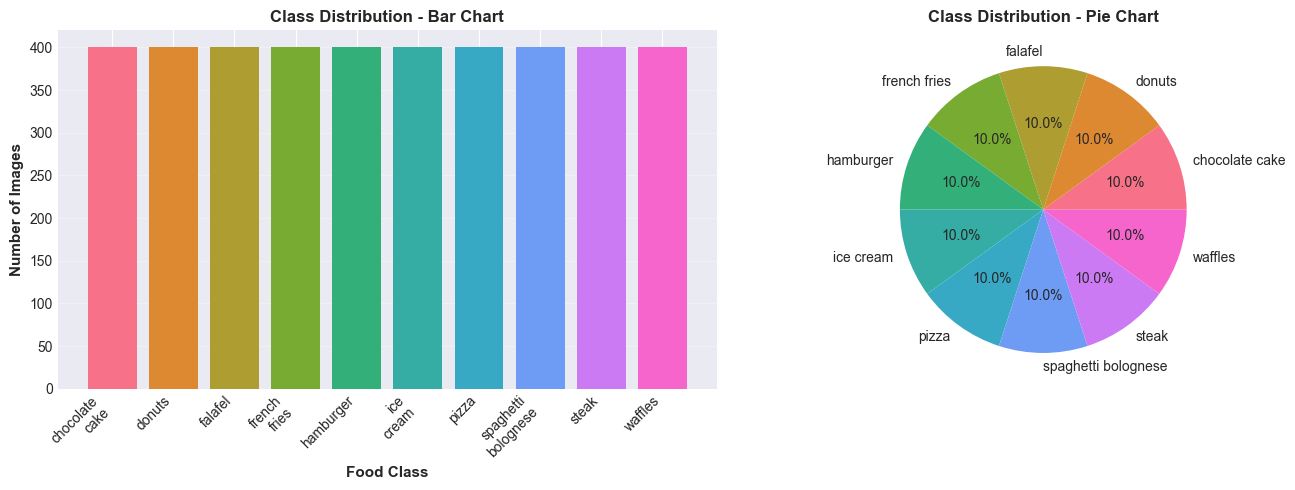

Class Distribution Statistics:

Min images in a class: 400
Max images in a class: 400
Mean images per class: 400.00
Std deviation: 0.00
Class balance ratio (max/min): 1.00


In [5]:
# Create visualizations for class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_names = list(data_info.keys())
class_counts = list(data_info.values())

axes[0].bar(range(len(class_names)), class_counts, color=sns.color_palette("husl", len(class_names)))
axes[0].set_xlabel('Food Class', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution - Bar Chart', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_xticklabels([name.replace('_', '\n') for name in class_names], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts, labels=[name.replace('_', ' ') for name in class_names], autopct='%1.1f%%',
            colors=sns.color_palette("husl", len(class_names)))
axes[1].set_title('Class Distribution - Pie Chart', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print class balance statistics
print("Class Distribution Statistics:\n")
counts = np.array(class_counts)
print(f"Min images in a class: {counts.min()}")
print(f"Max images in a class: {counts.max()}")
print(f"Mean images per class: {counts.mean():.2f}")
print(f"Std deviation: {counts.std():.2f}")
print(f"Class balance ratio (max/min): {counts.max() / counts.min():.2f}")

## 4. Load and Resize Images

In [8]:
# Define target image size for resizing
TARGET_SIZE = 128  # Smaller size for faster and more stable training

# Function to load and resize images
def load_and_resize_images(dataset_path, classes, target_size=224):
    # Load all images from the dataset and resize them to target size.
    # Returns: images (array), labels (array), class_names (list)
    images = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_path = dataset_path / class_name
        image_files = sorted(list(class_path.glob('*.jpg')))
        
        for img_path in image_files:
            try:
                # Load image
                img = Image.open(img_path).convert('RGB')
                # Resize image
                img_resized = img.resize((target_size, target_size), Image.LANCZOS)
                # Convert to numpy array
                img_array = np.array(img_resized)
                
                images.append(img_array)
                labels.append(class_idx)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue
        
        class_loaded_count = np.sum(np.array(labels) == class_idx)
        print(f"Loaded {class_loaded_count} images for class '{class_name}'")
    
    return np.array(images), np.array(labels), classes

# Load and resize images
X, y, class_names = load_and_resize_images(dataset_path, classes, TARGET_SIZE)


print("\nDataset Loaded and Resized")

print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Image dimensions: {TARGET_SIZE}x{TARGET_SIZE}x3 (RGB)")
print(f"Unique classes: {np.unique(y)}")

Loaded 400 images for class 'chocolate_cake'
Loaded 400 images for class 'donuts'
Loaded 400 images for class 'falafel'
Loaded 400 images for class 'french_fries'
Loaded 400 images for class 'hamburger'
Loaded 400 images for class 'ice_cream'
Loaded 400 images for class 'pizza'
Loaded 400 images for class 'spaghetti_bolognese'
Loaded 400 images for class 'steak'
Loaded 400 images for class 'waffles'

Dataset Loaded and Resized
Dataset shape: (4000, 128, 128, 3)
Labels shape: (4000,)
Image dimensions: 128x128x3 (RGB)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


## 5. Normalize Pixel Values

Original pixel value statistics:
  Min value: 0
  Max value: 255
  Mean value: 112.57
  Std deviation: 73.06

Normalized pixel value statistics (0-1 range):
  Min value: 0.0000
  Max value: 1.0000
  Mean value: 0.4414
  Std deviation: 0.2865


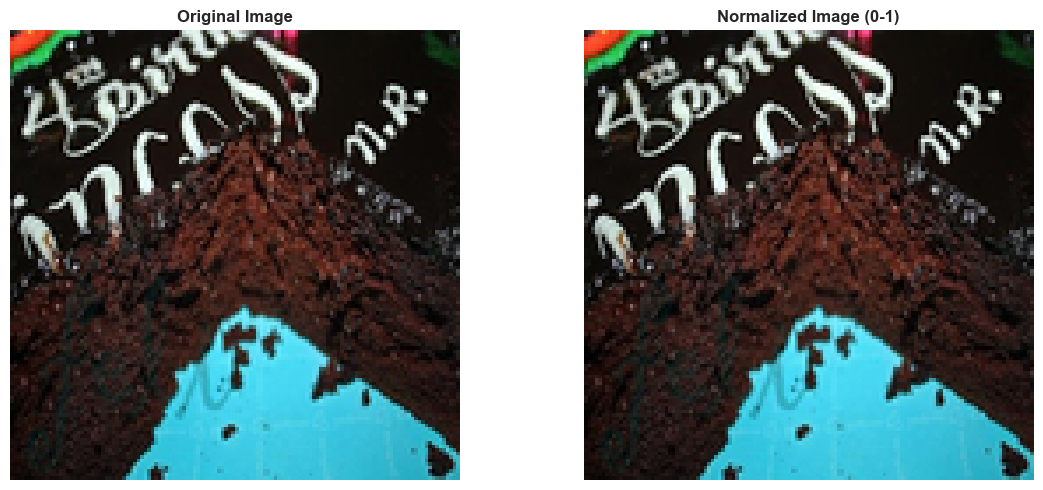

In [9]:
# Display original pixel value statistics
print("Original pixel value statistics:")
print(f"  Min value: {X.min()}")
print(f"  Max value: {X.max()}")
print(f"  Mean value: {X.mean():.2f}")
print(f"  Std deviation: {X.std():.2f}")

# Normalize pixel values to 0-1 range
X_normalized = X.astype('float32') / 255.0

# Display normalized pixel value statistics
print("\nNormalized pixel value statistics (0-1 range):")
print(f"  Min value: {X_normalized.min():.4f}")
print(f"  Max value: {X_normalized.max():.4f}")
print(f"  Mean value: {X_normalized.mean():.4f}")
print(f"  Std deviation: {X_normalized.std():.4f}")

# Visualize effect of normalization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original image
sample_idx = 0
axes[0].imshow(X[sample_idx].astype('uint8'))
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Normalized image
axes[1].imshow(X_normalized[sample_idx])
axes[1].set_title('Normalized Image (0-1)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Split Data into Training, Validation, and Testing Sets

In [10]:
# Define split ratios
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_normalized, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

# Second split: separate train and validation from remaining data (70% train, 15% val)
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size_adjusted, random_state=42, stratify=y_temp
)

print("Data Split Summary:\n")
print(f"\nTotal dataset size: {len(X_normalized):,} images")
print(f"\nTraining set size: {len(X_train):,} images ({len(X_train)/len(X_normalized)*100:.1f}%)")
print(f"Validation set size: {len(X_val):,} images ({len(X_val)/len(X_normalized)*100:.1f}%)")
print(f"Testing set size: {len(X_test):,} images ({len(X_test)/len(X_normalized)*100:.1f}%)")

# Verify label distribution in each split
print("\nLabel Distribution Across Splits:")


for set_name, y_set in [("Training", y_train), ("Validation", y_val), ("Testing", y_test)]:
    print(f"\n{set_name} set label distribution:")
    unique, counts = np.unique(y_set, return_counts=True)
    for label_idx, count in zip(unique, counts):
        print(f"  {class_names[label_idx]}: {count} images")

Data Split Summary:


Total dataset size: 4,000 images

Training set size: 2,800 images (70.0%)
Validation set size: 600 images (15.0%)
Testing set size: 600 images (15.0%)

Label Distribution Across Splits:

Training set label distribution:
  chocolate_cake: 280 images
  donuts: 280 images
  falafel: 280 images
  french_fries: 280 images
  hamburger: 280 images
  ice_cream: 280 images
  pizza: 280 images
  spaghetti_bolognese: 280 images
  steak: 280 images
  waffles: 280 images

Validation set label distribution:
  chocolate_cake: 60 images
  donuts: 60 images
  falafel: 60 images
  french_fries: 60 images
  hamburger: 60 images
  ice_cream: 60 images
  pizza: 60 images
  spaghetti_bolognese: 60 images
  steak: 60 images
  waffles: 60 images

Testing set label distribution:
  chocolate_cake: 60 images
  donuts: 60 images
  falafel: 60 images
  french_fries: 60 images
  hamburger: 60 images
  ice_cream: 60 images
  pizza: 60 images
  spaghetti_bolognese: 60 images
  steak: 60 images
 

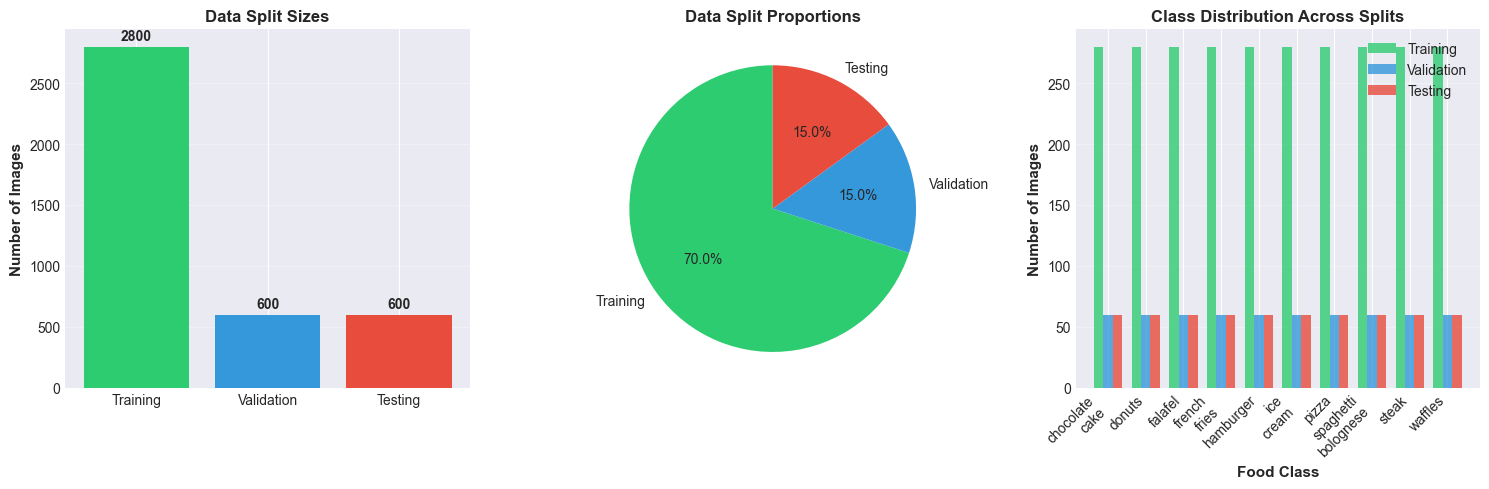

In [9]:
# Visualize the data split
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
split_names = ['Training', 'Validation', 'Testing']
split_sizes = [len(X_train), len(X_val), len(X_test)]
colors = ['#2ecc71', '#3498db', '#e74c3c']

# Bar chart of split sizes
axes[0].bar(split_names, split_sizes, color=colors)
axes[0].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[0].set_title('Data Split Sizes', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(split_sizes):
    axes[0].text(i, v + max(split_sizes)*0.02, str(v), ha='center', fontweight='bold')

# Pie chart of split proportions
axes[1].pie(split_sizes, labels=split_names, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Data Split Proportions', fontsize=12, fontweight='bold')

# Class distribution in train/val/test
y_sets = [y_train, y_val, y_test]
x_pos = np.arange(len(class_names))
width = 0.25

for i, (y_set, set_name, color) in enumerate(zip(y_sets, split_names, colors)):
    _, counts = np.unique(y_set, return_counts=True)
    axes[2].bar(x_pos + i*width, counts, width, label=set_name, color=color, alpha=0.8)

axes[2].set_xlabel('Food Class', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[2].set_title('Class Distribution Across Splits', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_pos + width)
axes[2].set_xticklabels([name.replace('_', '\n') for name in class_names], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Summary statistics
print("Final Dataset Summary:\n")
print(f"\nNumber of classes: {len(class_names)}")
print(f"Classes: {', '.join(class_names)}")
print(f"\nImage dimensions: {TARGET_SIZE}x{TARGET_SIZE}x3 (RGB)")
print(f"Pixel value range: [0.0, 1.0] (normalized)")
print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\nMemory usage:")
print(f"  Training: {X_train.nbytes / (1024**2):.2f} MB")
print(f"  Validation: {X_val.nbytes / (1024**2):.2f} MB")
print(f"  Testing: {X_test.nbytes / (1024**2):.2f} MB")
print(f"  Total: {(X_train.nbytes + X_val.nbytes + X_test.nbytes) / (1024**2):.2f} MB")

Final Dataset Summary:


Number of classes: 10
Classes: chocolate_cake, donuts, falafel, french_fries, hamburger, ice_cream, pizza, spaghetti_bolognese, steak, waffles

Image dimensions: 224x224x3 (RGB)
Pixel value range: [0.0, 1.0] (normalized)

Training set: (2800, 224, 224, 3)
Validation set: (600, 224, 224, 3)
Testing set: (600, 224, 224, 3)

Memory usage:
  Training: 1607.81 MB
  Validation: 344.53 MB
  Testing: 344.53 MB
  Total: 2296.88 MB


# Stage 2: Build a Custom CNN from Scratch

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,410 (16.08 MB)

 Trainable params: 4,214,410 (16.08 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 4,214,410
Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1500 - loss: 2.3945 - val_accuracy: 0.2150 - val_loss: 2.2602
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2489 - loss: 2.0993 - val_accuracy: 0.2333 - val_loss: 2.1392
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3221 - loss: 1.8962 - val_accuracy: 0.2883 - val_loss: 2.0659
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4150 - loss: 1.7028 - val_accuracy: 0.2917 - val_loss: 2.1948
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5129 - loss: 1.4394 - val_accuracy: 0.2583 - val_loss: 2.8470
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6021 - loss: 1.1894 - val_accuracy: 0.2683 - val_loss: 2.7882
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6729 - loss: 1.0532 - val_accuracy: 0.2650 - val_loss: 3.5765
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7211 - 

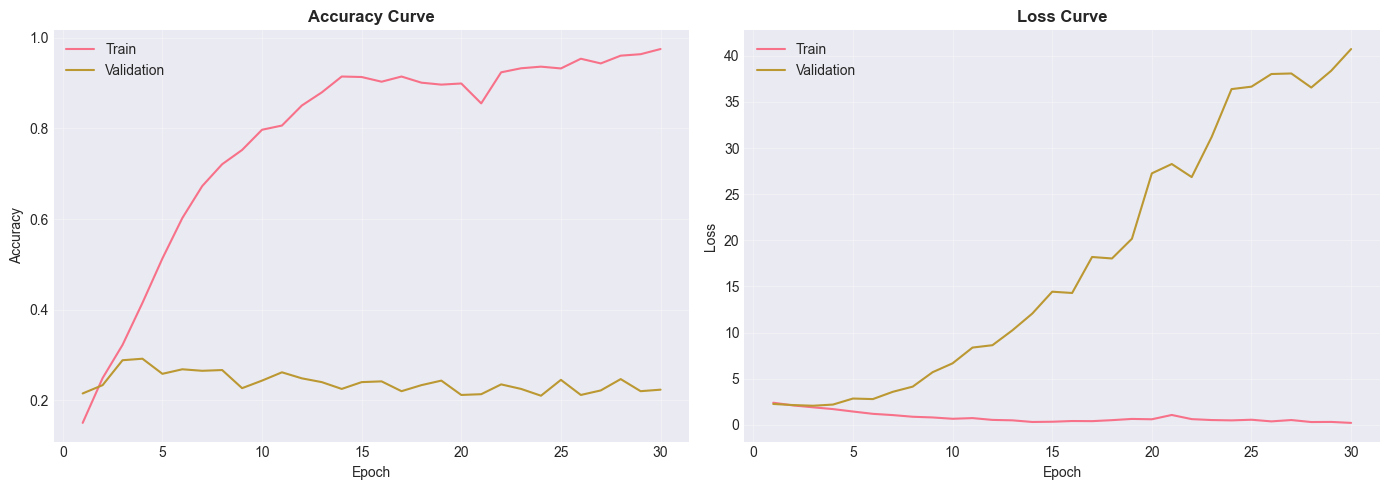


Best validation accuracy : 0.2917
Final validation accuracy: 0.2233
Final validation loss    : 40.7332
Test accuracy            : 0.2517


In [ ]:
# Stage 2: Custom CNN from scratch 
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

# Build the CNN manually
custom_cnn = models.Sequential([
    layers.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)),

    # Block 1 — low-level features (edges, textures)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — mid-level features
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to a vector
    layers.Flatten(),

    # Classifier head
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

custom_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary and trainable parameters
custom_cnn.summary()
print(f'\nTotal trainable parameters: {custom_cnn.count_params():,}')

# Train
history = custom_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

# Accuracy and loss curves
history_dict = history.history
epochs_range = range(1, len(history_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history_dict['accuracy'], label='Train')
axes[0].plot(epochs_range, history_dict['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_dict['loss'], label='Train')
axes[1].plot(epochs_range, history_dict['val_loss'], label='Validation')
axes[1].set_title('Loss Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Validation accuracy results
val_loss, val_acc = custom_cnn.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc = custom_cnn.evaluate(X_test, y_test, verbose=0)
best_val_acc = max(history_dict['val_accuracy'])
print(f'\nBest validation accuracy : {best_val_acc:.4f}')
print(f'Final validation accuracy: {val_acc:.4f}')
print(f'Final validation loss    : {val_loss:.4f}')
print(f'Test accuracy            : {test_acc:.4f}')

## Why CNNs are suitable for image classification
CNNs process images by scanning small local patches (kernels) across the entire image, so they naturally capture spatial patterns like edges, shapes, and textures regardless of where they appear. Fully connected networks would need to treat every pixel independently, leading to millions of parameters and poor generalization. CNNs share weights across positions, making them far more efficient and effective for images.

## Purpose of each layer
| Layer | Purpose |
|-------|---------|
| `Conv2D` | Applies learnable filters to extract visual features from the input. |
| `ReLU activation` | Introduces non-linearity so the network can learn complex decision boundaries. |
| `MaxPooling2D` | Downsamples feature maps, reducing size and computation while keeping the strongest activations. |
| `Flatten` | Converts the 2D feature maps into a 1D vector so Dense layers can process them. |
| `Dense` | Combines extracted features to form class-level decision boundaries. |
| `Softmax output` | Produces a probability distribution over the 10 food classes; the class with the highest probability is the prediction. |

## Trainable parameters
The model summary above lists the parameter count per layer. The total is reported after the summary.